# Mechanism of action

This tutorial runs on BBBC021, the field's reference benchmark: 38 compounds with published
mechanism labels, at one to seven concentrations each, downloaded and cached by
`mt.ds.bbbc021()`. The images are from {cite:t}`Caie_2010`; the profiles and the MOA benchmark
are from {cite:t}`Ljosa_2013`.

The questions are whether a profile tells us what a compound does and, where it does not,
which mechanisms morphology cannot separate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt

# Palette shared with the mantispy plotters (mt.pl.hits/mt.pl.cytotoxicity):
ACCENT = "crimson"  # observed / significant / the headline result to report (mt.pl.hits "hit")
NULL = "grey"  # null / shuffled / not-significant / background

## From wells to one signature per treatment

The preparation is the one from [Normalize, select, aggregate](../profiles/normalize_and_select.ipynb),
followed by one consensus signature per treatment.

In [2]:
adata = mt.ds.bbbc021()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
signatures = mt.tl.consensus(treated, method="median", min_replicates=1)
signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()

{
    "features kept": int(adata.n_vars),
    "treatments": int(signatures.n_obs),
    "mechanisms": int(signatures.obs["Metadata_MOA"].nunique()),
}

<path>:2: UserWarning: 2 of 467 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'features kept': 343, 'treatments': 103, 'mechanisms': 12}

103 treatments over 12 mechanisms, the shape of the published benchmark.

## Classifying

`tl.nn_moa_classify` assigns each treatment the mechanism of its nearest neighbor. The
`scheme` decides what the number means:

- `"nn"` allows any neighbor. A compound's nearest neighbor is usually the same compound at
  another concentration, so the task reduces to a profile finding its own compound.
- `"nsc"` (not-same-compound) excludes every neighbor with the same compound. The
  classifier has to generalize from one molecule to a different one with the same
  mechanism. The published benchmark uses this rule.

In [3]:
for scheme in ("nn", "nsc"):
    mt.tl.nn_moa_classify(signatures, scheme=scheme, key_added=scheme)

shares = signatures.obs["Metadata_MOA"].value_counts(normalize=True)
{
    "nn accuracy": round(signatures.uns["mantispy"]["nn"]["accuracy"], 3),
    "not-same-compound accuracy": round(signatures.uns["mantispy"]["nsc"]["accuracy"], 3),
    "largest class share (the honest chance level)": round(float(shares.iloc[0]), 3),
}

{'nn accuracy': 0.951,
 'not-same-compound accuracy': 0.777,
 'largest class share (the honest chance level)': 0.136}

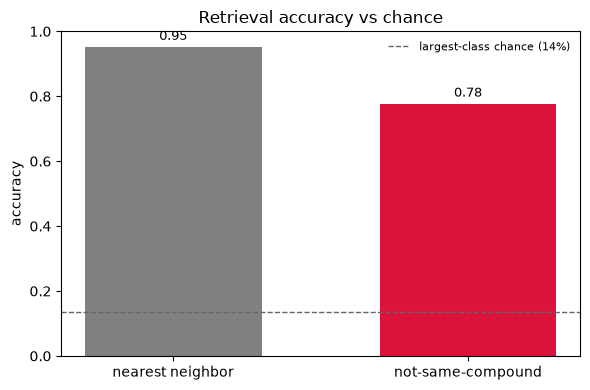

In [4]:
labels = ["nearest neighbor", "not-same-compound"]
accuracies = [
    signatures.uns["mantispy"]["nn"]["accuracy"],
    signatures.uns["mantispy"]["nsc"]["accuracy"],
]
chance = float(shares.iloc[0])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, accuracies, width=0.6, color=[NULL, ACCENT])
ax.axhline(chance, ls="--", lw=1, color="0.4", label=f"largest-class chance ({chance:.0%})")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set(ylabel="accuracy", ylim=(0, 1), title="Retrieval accuracy vs chance")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The two schemes give 0.95 and 0.78. The `nn` number mostly measures how well a profile
recognizes its own compound at another dose.

Against a largest-class share of 0.14, not-same-compound retrieval of 0.78 is a strong
result.

## What gets confused with what

An off-diagonal block in the confusion matrix usually reflects biology.

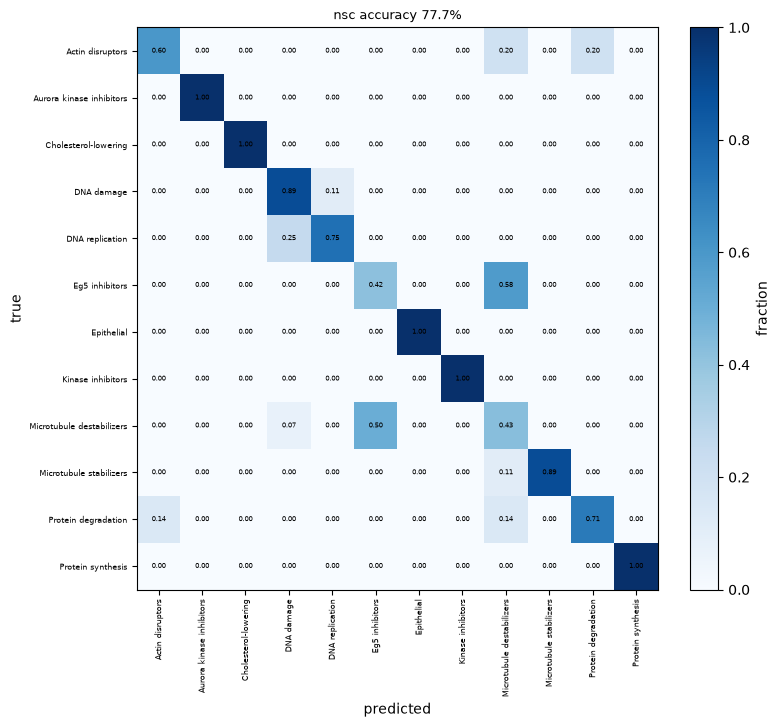

In [5]:
ax = mt.pl.moa_confusion(signatures, key="nsc")
plt.show()

In [6]:
confusion = signatures.uns["mantispy"]["nsc_confusion"]
confusion[confusion["true"] != confusion["predicted"]].nlargest(5, "count")

,true,predicted,count
5,Eg5 inhibitors,Microtubule destabilizers,7
6,Microtubule destabilizers,Eg5 inhibitors,7
14,DNA replication,DNA damage,2
15,Protein degradation,Actin disruptors,1
16,Protein degradation,Microtubule destabilizers,1


The largest confusion is symmetric and biologically expected: Eg5 inhibitors and microtubule
destabilizers, seven treatments each way. Eg5 is the kinesin that separates the centrosomes.
Inhibiting it gives a monopolar spindle, and destabilizing microtubules also arrests mitosis.
At these doses the two look alike under the microscope, which is a limit of the assay rather
than of the classifier.

The second is DNA damage against DNA replication, for the same reason: both stall the cell
cycle and both are read out through the DNA channel.

## Predicting a hidden mechanism

A blind test is more convincing. For each compound in turn, remove its mechanism label, use
`tl.moa_enrichment` to find what its neighborhood is enriched for, and compare the answer with
the removed label. `moa_enrichment` needs no label on the profile it scores, which is the
situation of an uncharacterized compound.

This cell hides each of the 38 compounds in turn, so it is the slowest cell on this page.

In [7]:
compounds = signatures.obs["Metadata_Compound"].astype(str)
truth = signatures.obs.groupby(compounds, observed=True)["Metadata_MOA"].first().astype(str)

# One copy, reused across compounds: each pass restores the labels, then hides the one under test.
blind = signatures.copy()
moa_labels = signatures.obs["Metadata_MOA"].astype(str).to_numpy()

records = []
for compound in truth.index:
    blind.obs["Metadata_MOA"] = moa_labels
    hidden = (compounds == compound).to_numpy()
    blind.obs.loc[hidden, "Metadata_MOA"] = "unknown"

    mt.tl.moa_enrichment(blind, k=10)
    table = blind.uns["mantispy"]["moa_enrichment"]
    asked = set(blind.obs.loc[hidden, "Metadata_Perturbation"].astype(str))
    rows = table[table["group"].isin(asked) & (table["moa"] != "unknown")]
    if rows.empty:
        continue
    predicted = rows.groupby("moa")["pvalue"].min().idxmin()
    records.append({"compound": compound, "true": truth[compound], "predicted": predicted})

blind_test = pd.DataFrame(records)
blind_test["correct"] = blind_test["true"] == blind_test["predicted"]
{
    "compounds tested": len(blind_test),
    "mechanism recovered": int(blind_test["correct"].sum()),
    "rate": round(float(blind_test["correct"].mean()), 3),
}

{'compounds tested': 38, 'mechanism recovered': 26, 'rate': 0.684}

In [8]:
blind_test[~blind_test["correct"]]

,compound,true,predicted,correct
0,ALLN,Protein degradation,Protein synthesis,False
2,AZ-C,Eg5 inhibitors,Microtubule destabilizers,False
4,AZ-U,Epithelial,Protein synthesis,False
8,MG-132,Protein degradation,Microtubule stabilizers,False
11,alsterpaullone,Kinase inhibitors,DNA damage,False
14,camptothecin,DNA replication,DNA damage,False
17,colchicine,Microtubule destabilizers,DNA damage,False
19,cytochalasin B,Actin disruptors,Protein synthesis,False
20,cytochalasin D,Actin disruptors,Protein synthesis,False
25,etoposide,DNA damage,DNA replication,False


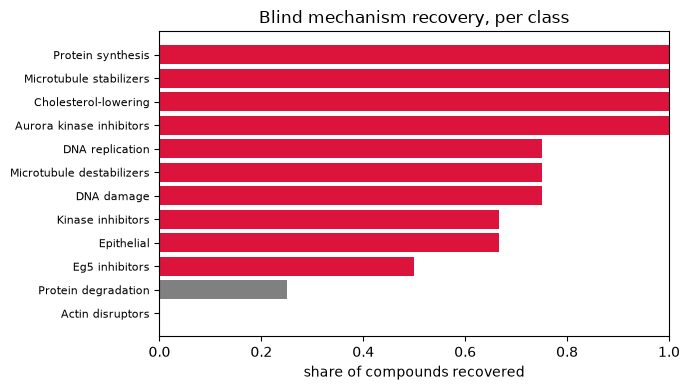

In [9]:
# Recovered fraction per true mechanism, sorted ascending so the classes that fail sit at the bottom.
recovered = blind_test.groupby("true")["correct"].mean().sort_values()
colours = np.where(recovered.to_numpy() >= 0.5, ACCENT, NULL)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(recovered)), recovered.to_numpy(), color=colours)
ax.set_yticks(range(len(recovered)), recovered.index, fontsize=8)
ax.set(xlabel="share of compounds recovered", xlim=(0, 1), title="Blind mechanism recovery, per class")
fig.tight_layout()
plt.show()

The two lowest bars are actin disruptors and protein degradation, the same classes the confusion matrix flagged: the blind test fails where the assay has no consistent readout, not at random.

Two thirds of the compounds have their mechanism recovered from morphology alone, without the label, against a
chance level of 0.11, the largest mechanism's share of the 38 compounds.

Ten of the twelve failures fall into three groups.

Some repeat the confusion matrix. Etoposide and camptothecin swap DNA damage and DNA replication in both
directions, and AZ-C, an Eg5 inhibitor, is predicted as a microtubule destabilizer. A mechanism that is hard for
the nearest-neighbor rule is also hard for the neighborhood test, so the two methods are consistent.

Some are most of a class. All three actin disruptors miss, each predicted as protein synthesis, so in the
neighbourhood test the actin phenotype does not separate that class. Three of the four
protein-degradation compounds miss as well: ALLN, MG-132 and lactacystin, three proteasome inhibitors with three
different wrong answers, while proteasome inhibitor I is recovered. The nearest-neighbour classifier above gets most
of these treatments right, so the failure belongs to the neighbourhood test. A class that fails in three different directions has no
consistent readout in this assay, which says more than a single confused pair.

One is unexpected: colchicine, a standard microtubule destabilizer, is predicted as DNA damage. Look at its
images before drawing further conclusions about it.

The other two are single compounds: AZ-U, labelled epithelial, is predicted as protein synthesis, and
alsterpaullone, a kinase inhibitor, as DNA damage.

## Which measurements separate the mechanisms

[Which measurements moved](../phenotypes/which_features_moved.ipynb) collapses each treatment's differential
features into families, such as tubulin intensity in the nucleus, and reads them against these mechanisms.

## Distances between mechanisms

`tl.edistance` with `reference=None` gives the full treatment-by-treatment energy
distance matrix, and `pl.distance_heatmap` orders it by mechanism so related treatments sit
together.

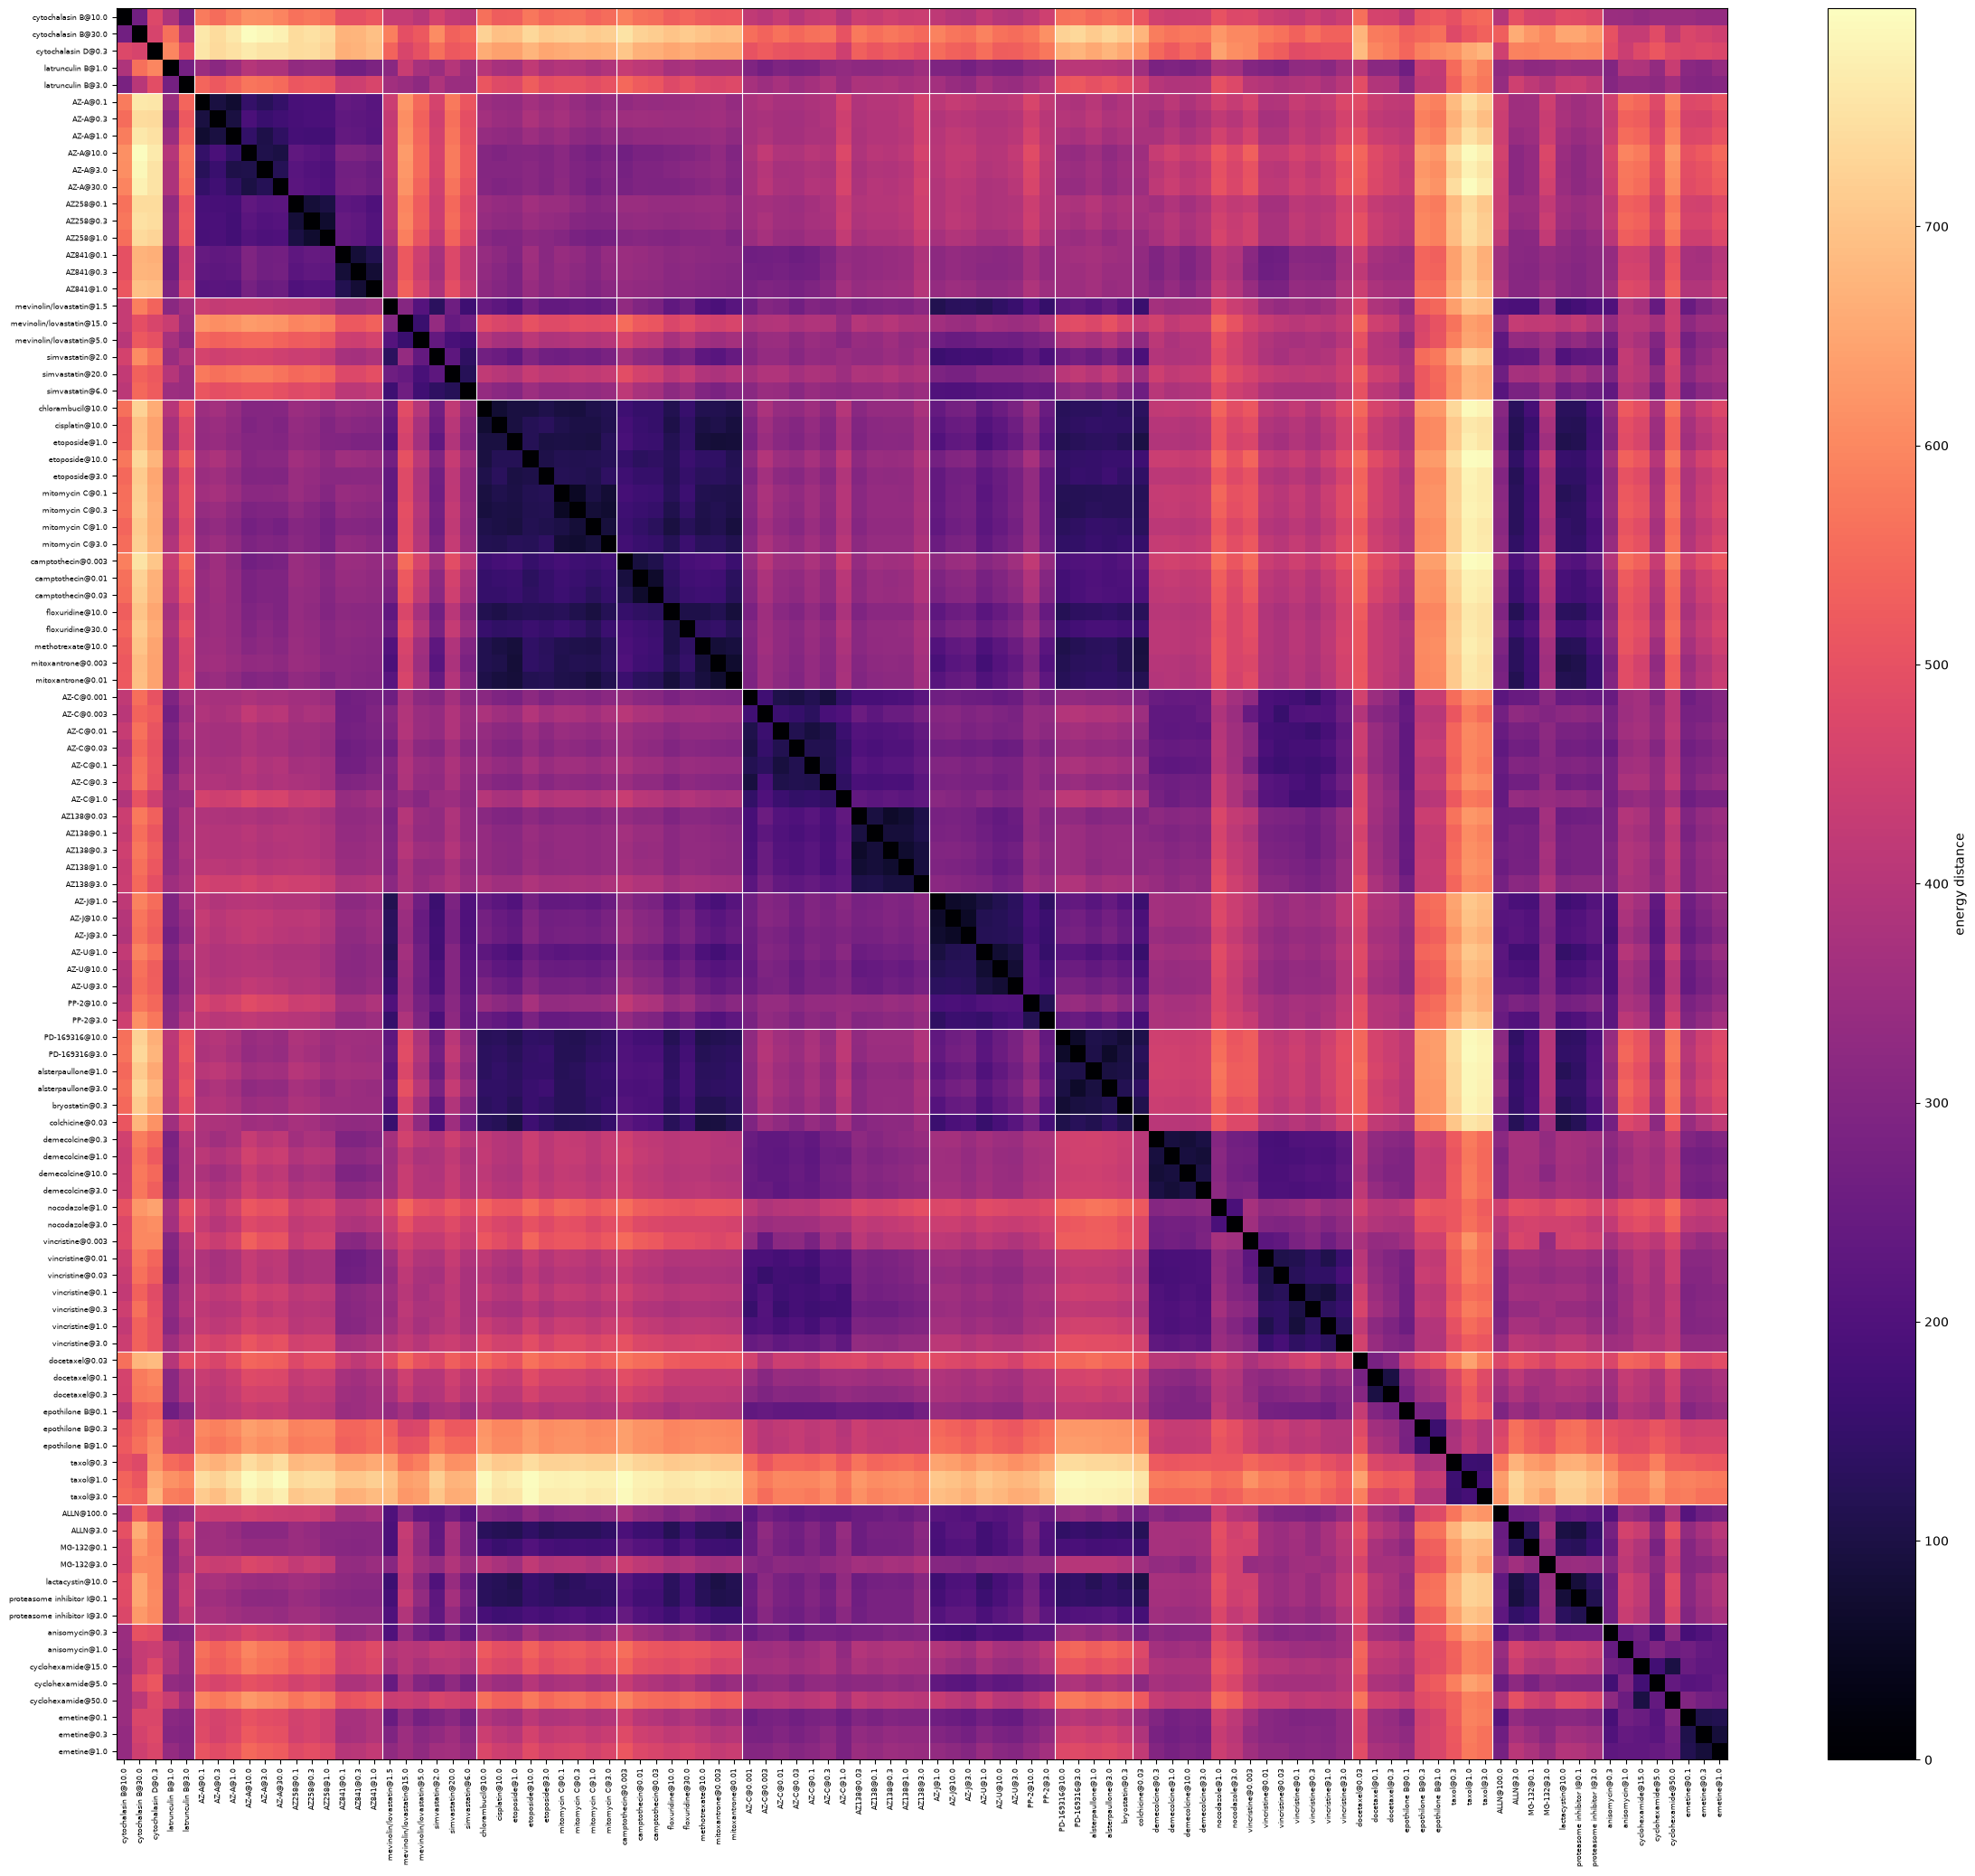

In [10]:
mt.tl.edistance(signatures, reference=None)
ax = mt.pl.distance_heatmap(signatures, groupby="Metadata_MOA")
plt.show()

## Scoring the whole map in one number

The heatmap shows the mechanism blocks. `metrics.known_relationships` scores them: of the
compound pairs the annotation relates, what share lands in either tail of the map's own
similarity distribution over all pairs? It is the benchmark {cite:t}`Celik_2024` selects
perturbative maps by, and it needs only an annotation of which perturbations belong together,
so the same call works for mechanisms here and for gene sets in a
[genetic screen](../genetics/crispr.ipynb).

Both tails count. Two compounds with opposite effects on one process are as related as two
with the same effect, and a one-sided test would score an inhibitor and an activator of the
same pathway as unrelated.

The profiles are aggregated to one per compound rather than one per treatment, so every
annotated pair is two different molecules. That is the not-same-compound rule from the top of
this page, applied to the annotation instead of to the classifier.

In [11]:
per_compound = treated.copy()
per_compound.obs["Metadata_Perturbation"] = per_compound.obs["Metadata_Compound"].astype(str)
compounds = mt.tl.consensus(per_compound, method="median", min_replicates=1)
compounds = compounds[compounds.obs["Metadata_MOA"].notna().to_numpy()].copy()

# source names a set, target one of its members. A mechanism is a set of compounds.
net = pd.DataFrame(
    {
        "source": compounds.obs["Metadata_MOA"].astype(str).to_numpy(),
        "target": compounds.obs["Metadata_Perturbation"].astype(str).to_numpy(),
    }
)

sizes = net["source"].value_counts()
{
    "compounds": int(compounds.n_obs),
    "mechanisms": int(sizes.size),
    "pairs sharing a mechanism": int((sizes * (sizes - 1) // 2).sum()),
    "pairs in total": compounds.n_obs * (compounds.n_obs - 1) // 2,
}

{'compounds': 38,
 'mechanisms': 12,
 'pairs sharing a mechanism': 44,
 'pairs in total': 703}

44 annotated pairs out of 703. Every compound here belongs to exactly one mechanism, so a map that carried no
information would put twice the tail size of them in the tails. `n_permutations` measures that level on the
map rather than assuming it: it shuffles which compound each annotation row names, keeping every mechanism's
size, and reports the mean recall over the shuffles as `null` and the share of shuffles that recall at least as
much as `p_value`.

In [12]:
rows = []
for percentile in (1.0, 5.0, 10.0):
    result = mt.metrics.known_relationships(compounds, net, percentile=percentile, n_permutations=100, seed=0).iloc[0]
    rows.append(
        {
            "tail width (%)": percentile,
            "twice the tail": 2 * percentile / 100,
            "shuffled annotation": float(result["null"]),
            "observed": float(result["value"]),
            "p": float(result["p_value"]),
        }
    )

pd.DataFrame(rows).round(3)

,tail width (%),twice the tail,shuffled annotation,observed,p
0,1.0,0.02,0.024,0.136,0.01
1,5.0,0.10,0.106,0.523,0.01
2,10.0,0.20,0.210,0.659,0.01


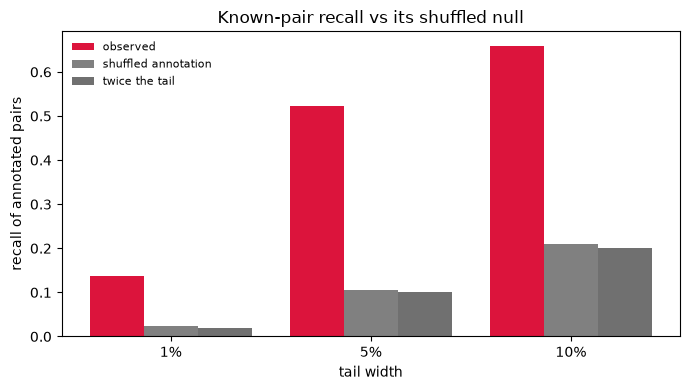

In [13]:
# Reuse the rows built just above; no re-run of known_relationships.
recall = pd.DataFrame(rows)
x = np.arange(len(recall))
width = 0.27

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width, recall["observed"], width, label="observed", color=ACCENT)
ax.bar(x, recall["shuffled annotation"], width, label="shuffled annotation", color=NULL)
ax.bar(x + width, recall["twice the tail"], width, label="twice the tail", color="#707070")
ax.set_xticks(x, [f"{p:g}%" for p in recall["tail width (%)"]])
ax.set(xlabel="tail width", ylabel="recall of annotated pairs", title="Known-pair recall vs its shuffled null")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

At every tail width the observed recall clears both nulls: it towers over the shuffled annotation and over twice the tail width, so the map relates the annotated pairs well beyond chance.

The shuffled annotation sits on twice the tail width at every width, as it should when every compound belongs
to one mechanism, and no shuffle reaches the observed recall. The observed recall is about five times chance at
the default width of 5% and about six times at the strictest.

Read this next to the not-same-compound accuracy of 0.78 from the top of the page. They
measure different things: the classifier asks whether the *nearest* neighbor of a compound
shares its mechanism, while this asks how many of the annotated pairs are extreme in the
whole distribution, including the pairs that are related but not nearest. The second is the
harder question, and the smaller number is not a worse result.

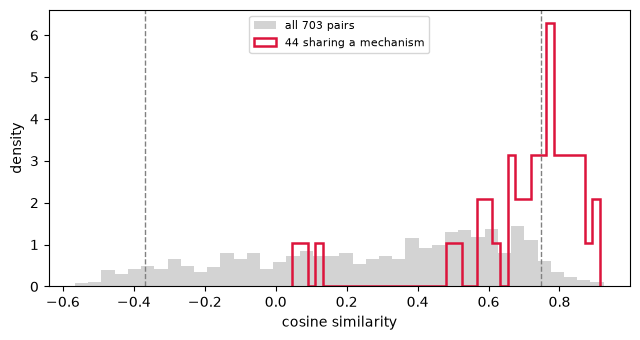

{'annotated in the upper tail': 23, 'annotated in the lower tail': 0}

In [14]:
from itertools import combinations

values = np.asarray(compounds.X, dtype=float)
unit = values / np.linalg.norm(values, axis=1, keepdims=True)
similarity = unit @ unit.T

upper = np.triu_indices(compounds.n_obs, 1)
position = {name: index for index, name in enumerate(net["target"])}
related = [
    (position[a], position[b])
    for _, block in net.groupby("source")
    for a, b in combinations(block["target"], 2)
]

background = similarity[upper]
annotated = np.array([similarity[i, j] for i, j in related])
low, high = np.quantile(background, [0.05, 0.95], method="inverted_cdf")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(background, bins=40, density=True, color="lightgrey", label=f"all {background.size} pairs")
ax.hist(
    annotated,
    bins=40,
    density=True,
    histtype="step",
    lw=1.8,
    color=ACCENT,
    label=f"{annotated.size} sharing a mechanism",
)
for cut in (low, high):
    ax.axvline(cut, color="grey", ls="--", lw=1)
ax.set_xlabel("cosine similarity")
ax.set_ylabel("density")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

{
    "annotated in the upper tail": int((annotated >= high).sum()),
    "annotated in the lower tail": int((annotated <= low).sum()),
}

The annotated pairs are shifted right of the background and pile up past the upper cut. None
of them reach the lower one: at this granularity sharing a mechanism means looking alike, not
looking opposed. The lower tail earns its place in genetic screens, where an activator and an
inhibitor of one pathway are annotated together, rather than in a compound panel like this.

Per mechanism, the same statistic says which classes the assay resolves. Each row is scored
against the same all-pairs background, so the rows are comparable.

In [15]:
per_mechanism = pd.DataFrame(
    [
        {
            "mechanism": mechanism,
            "compounds": len(block),
            "pairs": len(block) * (len(block) - 1) // 2,
            "recall": mt.metrics.known_relationships(compounds, block)["value"].iloc[0],
        }
        for mechanism, block in net.groupby("source")
        if len(block) > 1
    ]
)
per_mechanism.sort_values("recall", ascending=False).round(3)

,mechanism,compounds,pairs,recall
1,Aurora kinase inhibitors,3,3,1.000
2,Cholesterol-lowering,2,1,1.000
9,Microtubule stabilizers,3,3,1.000
5,Eg5 inhibitors,2,1,1.000
11,Protein synthesis,3,3,1.000
3,DNA damage,4,6,0.667
8,Microtubule destabilizers,4,6,0.500
0,Actin disruptors,3,3,0.333
7,Kinase inhibitors,3,3,0.333
6,Epithelial,3,3,0.333


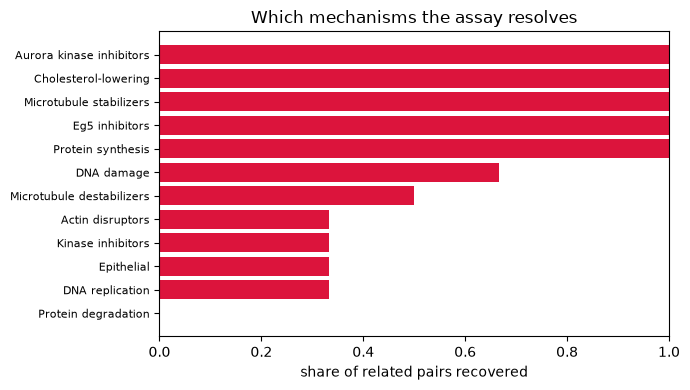

In [16]:
# barh draws bottom-to-top, so reverse the descending order to put the strongest mechanism on top.
ranked = per_mechanism.sort_values("recall", ascending=False).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(ranked)), ranked["recall"], color=ACCENT)
ax.set_yticks(range(len(ranked)), ranked["mechanism"], fontsize=8)
ax.set(xlabel="share of related pairs recovered", xlim=(0, 1), title="Which mechanisms the assay resolves")
fig.tight_layout()
plt.show()

Five mechanisms recover every pair: Aurora kinase inhibitors, Eg5 inhibitors, microtubule
stabilizers, protein synthesis inhibitors and the two cholesterol-lowering compounds. These
are the classes with one clear cellular readout.

One recovers none.
Protein degradation is the class where ALLN, MG-132 and lactacystin each drew a different
wrong answer in the blind test above; here their profiles are not even mutually extreme,
which is the same finding with no classifier in the way. Kinase inhibitors recovers one pair of three; the
label covers different kinases with different substrates, so there is no reason for its members
to converge on one morphology — the annotation is broad, not the assay blind.

That distinction is the point of reading the per-mechanism table rather than the single
number. A low overall recall can mean the map is poor, or it can mean the annotation groups
things the assay has no reason to group, and only the breakdown separates the two.

## Summary

- Report the not-same-compound number, or state which rule you used. The gap between the two
  is large enough to change conclusions.
- Chance is the largest class's share, not one over the number of classes.
- Confusions are hypotheses about the assay. The confusion between Eg5 inhibitors and
  microtubule destabilizers shows what these images can resolve.
- `metrics.known_relationships` scores the whole map against an annotation in one number, read against its
  shuffled-annotation null. The per-mechanism breakdown says whether a low number is the map or the annotation.
- `moa_enrichment` scores a compound without a label, as needed in a screen of
  uncharacterized molecules.

Next: [Concentration response](dose_response.ipynb), on how much of a compound was needed.